# Fourier Analysis of Learned Embeddings

Trains 3 models to grokking, then analyses the Fourier structure of their
embedding matrices. Tests whether GELU, ReLU, and Transformer all converge
to the same sparse Fourier representation (Nanda et al. 2023).

**Est. T4 runtime: ~5 min training + instant analysis**

> Runtime → Change runtime type → T4 GPU

In [1]:
import torch, time, random, numpy as np, pandas as pd
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt, warnings
from itertools import product as iproduct
from copy import deepcopy
from torch.amp import autocast

assert torch.cuda.is_available(), "Need T4 GPU!"
print("GPU:", torch.cuda.get_device_name(0))
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
print("PyTorch:", torch.__version__)

P=97; TRAIN_FRACTION=0.2; CLIP=1.0; DEVICE="cuda"
LOG_EVERY = 2_000

def make_data(seed=0, op="add"):
    random.seed(seed)
    if op == "add":
        pairs = list(iproduct(range(P), range(P)))
        targets = lambda x: (x[:,0]+x[:,1])%P
    else:  # mul — exclude a=0 or b=0
        pairs = [(a,b) for a in range(1,P) for b in range(1,P)]
        targets = lambda x: (x[:,0]*x[:,1])%P
    random.shuffle(pairs)
    n = int(len(pairs)*TRAIN_FRACTION)
    def tt(d):
        x = torch.tensor(d, dtype=torch.long, device=DEVICE)
        return x, targets(x)
    return tt(pairs[:n]), tt(pairs[n:])

def accuracy(logits, y): return (logits.argmax(-1)==y).float().mean().item()

class MLP(nn.Module):
    def __init__(self, width=512, depth=4, act=nn.GELU):
        super().__init__()
        self.embed = nn.Embedding(P, width)
        layers = []
        for _ in range(depth): layers += [nn.Linear(width,width), act()]
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(width, P)
    def forward(self, x):
        return self.out(self.mlp(self.embed(x[:,0])+self.embed(x[:,1])))

class Transformer(nn.Module):
    def __init__(self, width=512, heads=4):
        super().__init__()
        self.embed     = nn.Embedding(P, width)
        self.pos_embed = nn.Parameter(torch.randn(2,width)*0.02)
        enc = nn.TransformerEncoderLayer(d_model=width, nhead=heads,
            dim_feedforward=width*4, activation="gelu", dropout=0.0,
            batch_first=True, norm_first=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            self.transformer = nn.TransformerEncoder(enc, num_layers=1)
        self.out = nn.Linear(width, P)
    def forward(self, x):
        h = self.embed(x)+self.pos_embed
        return self.out(self.transformer(h).mean(1))

# ── CUDA-graph training with in-graph weight norm ──────────────────────────
def cuda_graph_train(model, optimizer, tx, ty, vx, vy,
                     steps=400_000, log_every=LOG_EVERY):
    """
    Full CUDA graph training loop.
    Weight norm is computed INSIDE the graph into a static buffer —
    zero CPU syncs during training steps.
    """
    model.train()

    # Static buffer for weight norm — written by graph, read at eval
    wn_buf = torch.zeros(1, device=DEVICE)

    # Warmup: 11 normal steps to trigger torch.compile
    for _ in range(11):
        optimizer.zero_grad(set_to_none=True)
        F.cross_entropy(model(tx), ty).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
    torch.cuda.synchronize()

    # Capture graph: forward + backward + clip + step + weight norm
    g = torch.cuda.CUDAGraph()
    optimizer.zero_grad(set_to_none=True)
    with torch.cuda.graph(g):
        loss_g = F.cross_entropy(model(tx), ty)
        loss_g.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
        # Compute RMS weight norm inside graph — no CPU sync needed
        sq_sum = torch.zeros(1, device=DEVICE)
        n_params = 0
        for p in model.parameters():
            sq_sum += p.detach().pow(2).sum()
            n_params += p.numel()
        wn_buf.copy_(torch.sqrt(sq_sum / n_params))
    torch.cuda.synchronize()

    T_train = T_test = None
    history = []   # {step, train_acc, test_acc, weight_norm}
    t0 = time.time()

    for step in range(steps):
        g.replay()   # entire step: fwd+bwd+opt+wn — no Python overhead

        if step % log_every == 0:
            torch.cuda.synchronize()   # sync once per LOG_EVERY
            model.eval()
            with torch.no_grad(), autocast("cuda"):
                tr = accuracy(model(tx), ty)
                te = accuracy(model(vx), vy)
            model.train()
            wn = wn_buf.item()   # single scalar read, already on CPU buffer
            history.append({"step":step,"train":tr,"test":te,"weight_norm":wn})

            if T_train is None and tr >= 0.99: T_train = step
            if T_test  is None and te >= 0.99:
                T_test = step
                print(f"    GROKKED step={step} T_train={T_train} "
                      f"delay={T_test-T_train} wn={wn:.4f} "
                      f"t={(time.time()-t0)/60:.1f}m")
                break
            if step % (log_every*10) == 0:
                print(f"    step={step:>7} tr={tr:.3f} te={te:.3f} "
                      f"wn={wn:.3f} t={(time.time()-t0)/60:.1f}m")

    return T_train, T_test, history


def run_config(name, model_factory, opt_factory, seed=0, steps=400_000, op="add"):
    """Run a single configuration and return results."""
    print(f"  {name} seed={seed}")
    torch.manual_seed(seed)
    (tx,ty),(vx,vy) = make_data(seed, op=op)
    model = torch.compile(model_factory().to(DEVICE))
    opt   = opt_factory(model)
    T_train, T_test, history = cuda_graph_train(model, opt, tx, ty, vx, vy, steps)
    delay = (T_test-T_train) if (T_train and T_test) else None
    return {"name":name,"seed":seed,"T_train":T_train,"T_test":T_test,
            "delay":delay,"history":history,"model":model}

print("Setup complete. CUDA graph training ready.")


GPU: Tesla T4
PyTorch: 2.10.0+cu128
Setup complete. CUDA graph training ready.


In [3]:
# Train 3 models to grokking — ~5 min total
FOURIER_CONFIGS = [
    ("MLP_GELU",
     lambda: MLP(width=512, depth=4, act=nn.GELU),
     lambda m: torch.optim.SGD(m.parameters(), lr=3e-2, weight_decay=1e-3, momentum=0.9)),
    ("MLP_ReLU",
     lambda: MLP(width=512, depth=4, act=nn.ReLU),
     lambda m: torch.optim.SGD(m.parameters(), lr=3e-2, weight_decay=1e-3, momentum=0.9)),
    ("Transformer",
     lambda: Transformer(),
     lambda m: torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=5.0, capturable=True)),
]

trained = {}
for name, mf, of in FOURIER_CONFIGS:
    print(f"\n=== {name} ===")
    t0 = time.time()
    r = run_config(name, mf, of, seed=0, steps=400_000)
    print(f"  done in {(time.time()-t0)/60:.1f}m  delay={r['delay']}")
    trained[name] = r["model"]
print("\nAll models trained.")


=== MLP_GELU ===
  MLP_GELU seed=0
    step=      0 tr=0.020 te=0.010 wn=0.209 t=0.0m
    step=  20000 tr=1.000 te=0.274 wn=0.028 t=1.4m
    GROKKED step=28000 T_train=2000 delay=26000 wn=0.0225 t=2.0m
  done in 2.0m  delay=26000

=== MLP_ReLU ===
  MLP_ReLU seed=0
    step=      0 tr=0.018 te=0.008 wn=0.209 t=0.0m
    step=  20000 tr=1.000 te=0.207 wn=0.026 t=1.4m
    step=  40000 tr=1.000 te=0.216 wn=0.025 t=2.8m
    step=  60000 tr=1.000 te=0.268 wn=0.025 t=4.1m
    step=  80000 tr=1.000 te=0.983 wn=0.021 t=5.5m
    GROKKED step=82000 T_train=2000 delay=80000 wn=0.0211 t=5.7m
  done in 5.7m  delay=80000

=== Transformer ===
  Transformer seed=0
    step=      0 tr=0.473 te=0.067 wn=0.120 t=0.1m
    GROKKED step=14000 T_train=2000 delay=12000 wn=0.0161 t=8.0m
  done in 8.0m  delay=12000

All models trained.


In [8]:

# ── Fourier analysis (instant — no GPU needed after training) ─────────────
def fourier_spectrum(W_E):
    """DFT over residue dimension, return sorted energy per frequency."""
    P_dim = W_E.shape[0]
    W_freq = torch.fft.fft(W_E.float(), dim=0)   # [P, d]
    energy = W_freq.abs().pow(2).sum(dim=1)       # [P] — sum over embedding dim
    energy = energy[:P_dim//2].numpy()            # positive freqs only
    freqs  = np.arange(len(energy))
    return freqs, energy

def top_k_concentration(W_E, k=5):
    _, en = fourier_spectrum(W_E)
    return en[np.argsort(en)[-k:]].sum() / en.sum()

def embed_2d_projection(W_E, freq1, freq2):
    """Project each embedding vector onto two Fourier basis vectors.
    W_E: [P, d]  ->  project each of the P residue embeddings (dim-d)
    onto the Fourier basis vectors (also dim-d) built from sin/cos patterns.
    We build the basis vectors in embedding space, not residue space.
    """
    P_dim, d = W_E.shape
    t = np.arange(P_dim)
    # Build [d]-dim basis vectors by weighting embedding dims by sin/cos patterns
    # Standard approach (Nanda et al.): project W_E onto the left singular
    # vectors of the Fourier matrix. Simpler: use the DFT directly.
    W = W_E.float().numpy()  # [P, d]
    # Take DFT along the residue (P) dimension -> [P, d]
    W_fft = np.fft.fft(W, axis=0)
    # The projection onto frequency f is the magnitude of W_fft[f]
    # For 2D scatter: use real and imaginary parts of the top-2 freq components
    p1 = W_fft[freq1].real   # [d] — real part of freq1 component for each embed dim
    p2 = W_fft[freq2].real   # [d]
    # Project each residue's embedding onto these directions
    # W: [P, d], p1: [d] -> dot product per residue -> [P]
    proj1 = W @ p1 / (np.linalg.norm(p1) + 1e-8)
    proj2 = W @ p2 / (np.linalg.norm(p2) + 1e-8)
    return proj1, proj2

# Collect results
print("=== FOURIER CONCENTRATION SUMMARY ===")
fourier_results = {}
for name, model in trained.items():
    W_E = model.embed.weight.detach().cpu()
    freqs, energy = fourier_spectrum(W_E)
    top5_idx  = np.argsort(energy)[-5:]
    conc      = top_k_concentration(W_E)
    fourier_results[name] = {"freqs":freqs,"energy":energy,
                              "top5":sorted(top5_idx.tolist()),"conc":conc,"W_E":W_E}
    print(f"  {name:<20} top-5 freqs={sorted(top5_idx.tolist())}  "
          f"concentration={conc:.4f}")


=== FOURIER CONCENTRATION SUMMARY ===
  MLP_GELU             top-5 freqs=[6, 12, 21, 37, 46]  concentration=0.7469
  MLP_ReLU             top-5 freqs=[6, 7, 11, 16, 21]  concentration=0.7561
  Transformer          top-5 freqs=[0, 16, 29, 32, 34]  concentration=0.9855


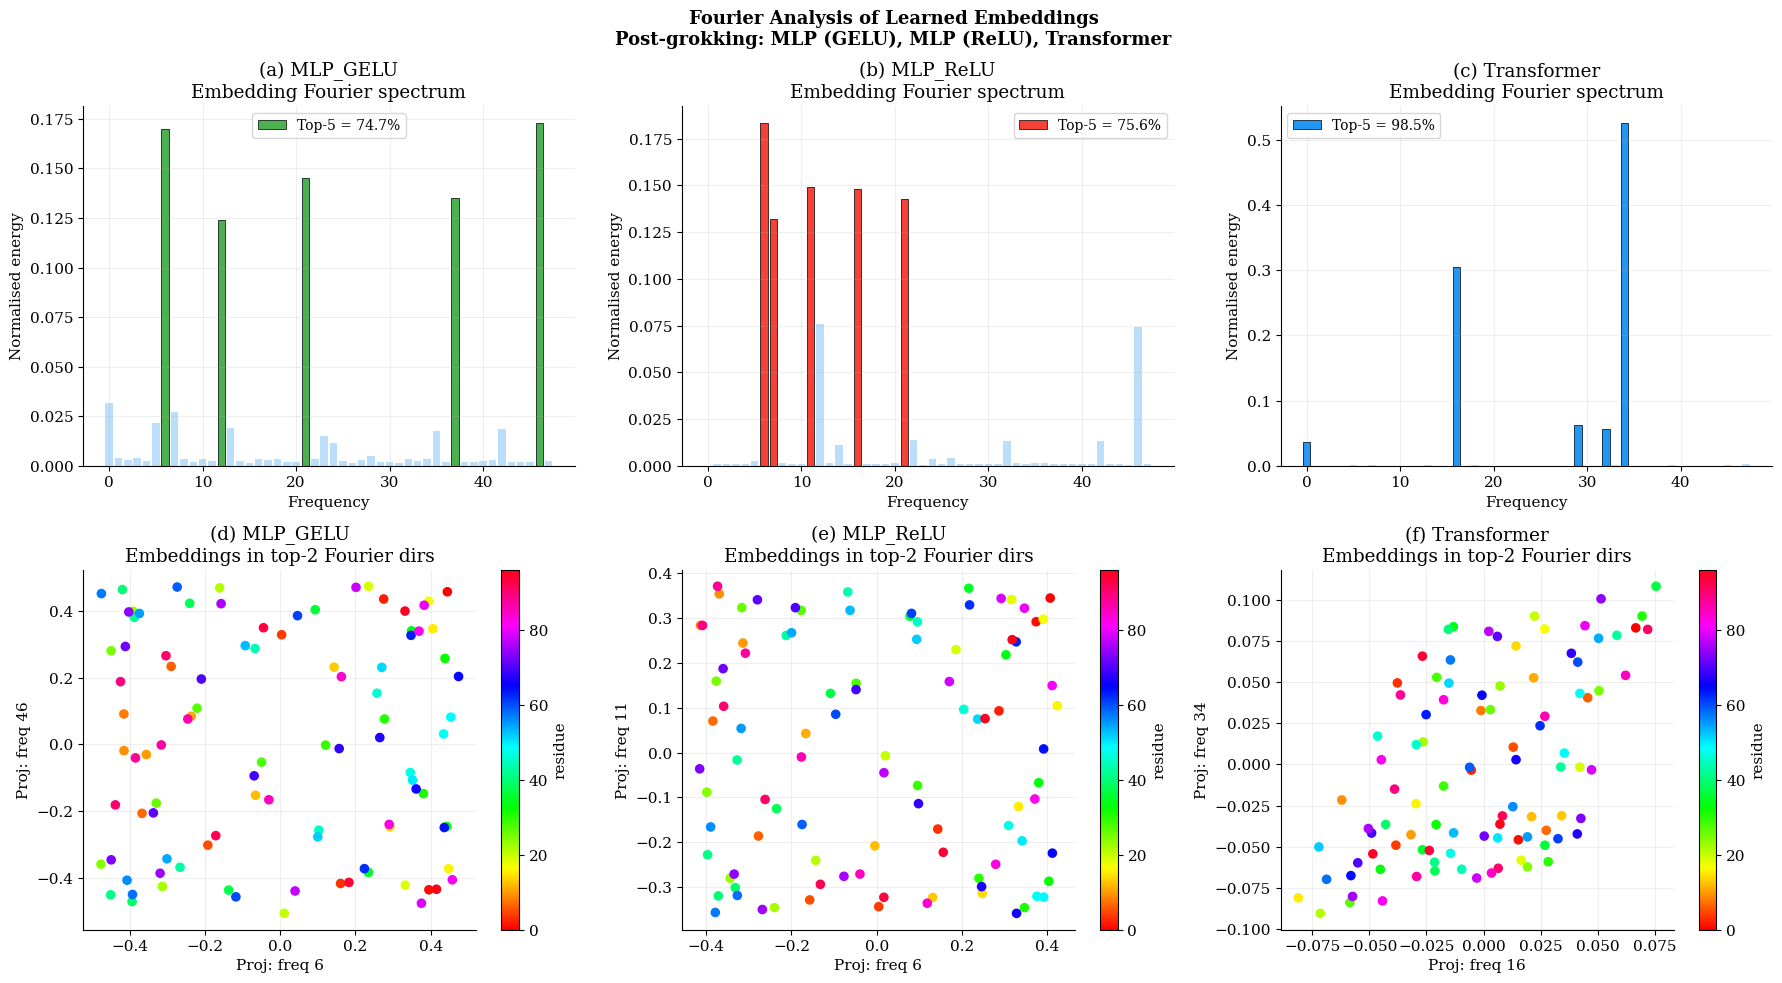

Saved: fig_fourier_analysis.png


In [9]:
plt.rcParams.update({"font.family":"serif","font.size":11,
    "axes.spines.top":False,"axes.spines.right":False})
COLORS2 = {"MLP_GELU":"#4CAF50","MLP_ReLU":"#F44336","Transformer":"#2196F3"}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Fourier energy spectra
for ax, (name, res) in zip(axes[0], fourier_results.items()):
    freqs, energy = res["freqs"], res["energy"]
    norm_energy   = energy / energy.sum()
    ax.bar(freqs, norm_energy, color="#BBDEFB", edgecolor="none", width=0.8)
    ax.bar(res["top5"], norm_energy[res["top5"]], color=COLORS2[name],
           edgecolor="black", lw=0.5, width=0.8,
           label=f"Top-5 = {res['conc']:.1%}")
    ax.set(xlabel="Frequency", ylabel="Normalised energy",
           title=f"({'abc'[list(fourier_results).index(name)]}) {name}\nEmbedding Fourier spectrum")
    ax.legend(fontsize=10); ax.grid(alpha=0.2)

# Row 2: 2D Fourier projections
for ax, (name, res) in zip(axes[1], fourier_results.items()):
    top2 = sorted(np.argsort(res["energy"])[-2:].tolist())
    p1, p2 = embed_2d_projection(res["W_E"], top2[0], top2[1])
    sc = ax.scatter(p1, p2, c=np.arange(P), cmap="hsv", s=35, zorder=3)
    plt.colorbar(sc, ax=ax, label="residue")
    ax.set(xlabel=f"Proj: freq {top2[0]}",
           ylabel=f"Proj: freq {top2[1]}",
           title=f"({'def'[list(fourier_results).index(name)]}) {name}\n"
                 f"Embeddings in top-2 Fourier dirs")
    ax.grid(alpha=0.2)

fig.suptitle("Fourier Analysis of Learned Embeddings\n"
             "Post-grokking: MLP (GELU), MLP (ReLU), Transformer",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_fourier_analysis.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: fig_fourier_analysis.png")
